# Gini DR


In [ ]:
import numpy as np
import pandas as pd
from fastwoe.metrics import somersd_xy
from matplotlib import pyplot as plt
from sklearn.linear_model import LogisticRegression

%config InlineBackend.figure_format = 'retina'

1.4686170171421287


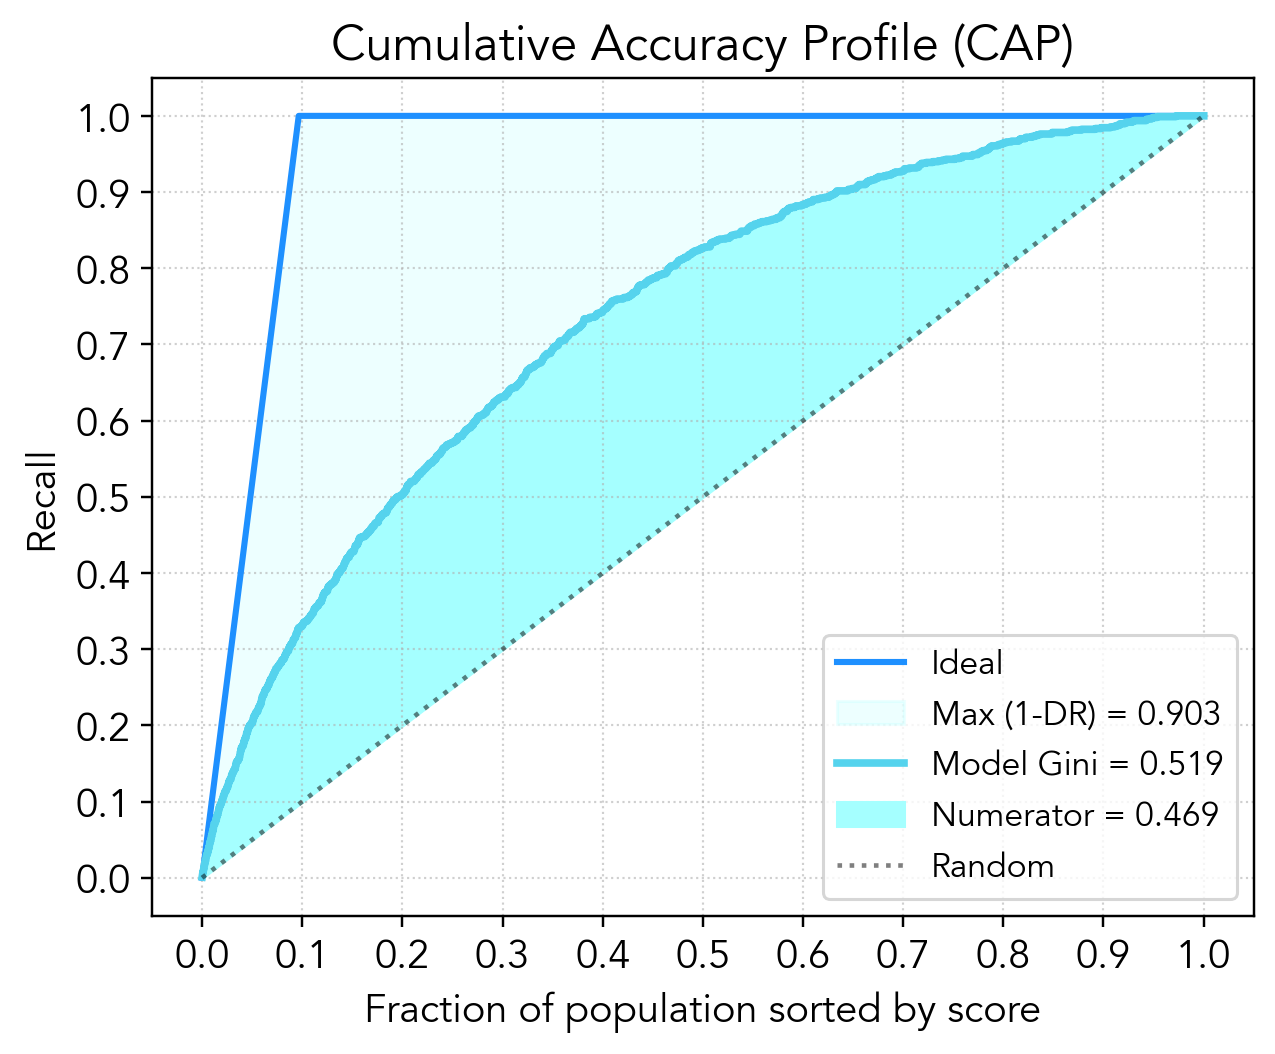

In [ ]:
# Generate population
TRUE_BAD_RATE: float = 0.1
N: int = 10_000
true_labels = np.random.binomial(1, TRUE_BAD_RATE, N)

# Use Font Avenir
plt.rcParams["font.family"] = "Avenir"
plt.rcParams["font.size"] = 13

np.random.seed(0)


def _d_from_auc(desired_auc: float) -> float:
    """Calculate separation d for N(0,1) vs N(d,1) distributions.

    Args:
        desired_auc: Target AUC value.

    Returns:
        Separation parameter d that achieves the desired AUC.
    """
    t = np.sqrt(np.log(1 / (1 - desired_auc) ** 2))
    z = t - (
        (2.515517 + 0.802853 * t + 0.0103328 * t**2)
        / (1 + 1.432788 * t + 0.189269 * t**2 + 0.001308 * t**3)
    )
    return z * np.sqrt(2)


def generate_scores_for_gini(
    labels: np.ndarray, target_gini: float, st_dev: float = 0.30
) -> np.ndarray:
    """Generate scores that achieve approximately target Gini coefficient.

    Args:
        labels: Binary labels (0/1) for the population.
        target_gini: Target Gini coefficient (e.g., 0.4 for 40% Gini).
        st_dev: Standard deviation for score distributions.

    Returns:
        Array of probability scores between 0 and 1.
    """
    desired_auc = (target_gini + 1) / 2
    d_unit = _d_from_auc(desired_auc)
    d = d_unit * st_dev

    n_event = int(labels.sum())
    n_non_event = len(labels) - n_event
    x_event = np.random.normal(d, st_dev, n_event)
    x_non_event = np.random.normal(0, st_dev, n_non_event)

    x = np.empty(len(labels))
    x[labels == 0] = x_non_event
    x[labels == 1] = x_event

    desired_mean = -2.0
    desired_std = 0.399522
    x = (x - np.mean(x)) * (desired_std / np.std(x)) + desired_mean
    x_min = np.min(x)
    x_range = np.max(x) - x_min
    if x_range > 0:
        desired_min = -2.935578
        desired_max = -1.173120
        x = (x - x_min) * (desired_max - desired_min) / x_range + desired_min
    return 1 / (1 + np.exp(-x))


def calibrate_scores(scores: np.ndarray, labels: np.ndarray) -> np.ndarray:
    """Calibrate probability scores using logistic regression.

    Args:
        scores: Uncalibrated probability scores.
        labels: True binary labels.

    Returns:
        Calibrated probability scores.
    """
    lr = LogisticRegression(penalty=None)
    logit_scores = np.log(scores / (1 - scores))
    lr.fit(logit_scores.reshape(-1, 1), labels)
    return lr.predict_proba(logit_scores.reshape(-1, 1))[:, 1]


def plot_performance(score, label):
    """
    Plot CAP curve for a single model with area visualization.

    Parameters:
    -----------
    score : pd.Series or np.ndarray
        Model scores/predictions
    label : pd.Series or np.ndarray
        True binary labels (0/1)

    Returns:
    --------
    cap_data : pd.DataFrame
        CAP curve data with cumulative metrics
    """
    # Normalize inputs
    if isinstance(score, pd.Series):
        score = score.values
    if isinstance(label, pd.Series):
        label = label.values

    # Calculate Gini
    # auc = roc_auc_score(label, score)
    # gini = 2 * auc - 1
    gini = somersd_xy(score, label).statistic

    # Prepare data
    cap_data = pd.DataFrame({"prediction": score, "label": label})
    cap_data = cap_data.sort_values(by="prediction", ascending=False).reset_index(
        drop=True
    )

    # Calculate cumulative metrics
    cap_data["id"] = cap_data.index
    total_id = cap_data["id"].max()
    cap_data["cum_id"] = (1 + cap_data["id"]) / total_id

    cumulative_bad = cap_data["label"].cumsum()
    total_bad = cap_data["label"].sum()
    cap_data["cumulative_bad"] = cumulative_bad / total_bad

    # Calculate area under CAP
    X = np.concatenate([[0], cap_data["cum_id"].values])
    Y = np.concatenate([[0], cap_data["cumulative_bad"].values])

    # Calculate Gini components
    DR = label.mean()
    trapezoid_sum = np.sum((Y[1:] + Y[:-1]) * (X[1:] - X[:-1]))
    print(trapezoid_sum)
    numerator = trapezoid_sum - 1
    denominator = 1 - DR

    # Create plot
    _, ax1 = plt.subplots(figsize=(6, 5), dpi=110)

    # Plot ideal CAP curve
    bad_rate = label.mean()
    ideal = [0, bad_rate, 1], [0, 1, 1]
    ax1.plot(ideal[0], ideal[1], color="dodgerblue", label="Ideal", linewidth=2)

    # Fill area for denominator visualization (between ideal and random)
    ax1.fill_between(
        ideal[0],
        ideal[0],
        ideal[1],
        alpha=0.2,
        color="#A5FFFF",
        label=f"Max (1-DR) = {denominator:.3f}",
    )

    # Plot model CAP curve
    ax1.plot(
        cap_data["cum_id"],
        cap_data["cumulative_bad"],
        label=f"Model Gini = {gini:.3f}",
        color="#55d3ed",
        linewidth=2.5,
    )

    # Fill area between model and random (numerator/2)
    ax1.fill_between(
        cap_data["cum_id"],
        cap_data["cum_id"],  # random line
        cap_data["cumulative_bad"],
        color="#A5FFFF",
        label=f"Numerator = {numerator:.3f}",
    )

    # Plot random line
    ax1.plot(
        [0, 1], [0, 1], linestyle="dotted", color="black", alpha=0.5, label="Random"
    )

    # Format plot
    ax1.set_xticks(np.arange(0, 1.1, 0.1))
    ax1.set_yticks(np.arange(0, 1.1, 0.1))
    ax1.set_xlabel("Fraction of population sorted by score")
    ax1.set_ylabel("Recall")
    ax1.set_title("Cumulative Accuracy Profile (CAP)", fontsize=16)
    ax1.grid(True, which="both", linestyle="dotted", linewidth=0.7, alpha=0.6)
    ax1.legend(loc="lower right", fontsize=11)

    plt.tight_layout()

    return cap_data, gini


def calculate_gini_with_dr(scores: np.ndarray, labels: np.ndarray) -> float:
    """
    Calculate Gini coefficient accounting for default rate.

    Formula: GINI = [Σ(Yi + Yi-1)(Xi - Xi-1) - 1] / (1 - DR)

    Parameters:
    -----------
    scores : np.ndarray
        Model probability scores
    labels : np.ndarray
        Binary labels (1 = default/bad, 0 = good)

    Returns:
    --------
    gini : float
        Gini coefficient
    """
    # Create dataframe and sort by score
    cap_data = pd.DataFrame({"prediction": scores, "label": labels})
    cap_data = cap_data.sort_values(by="prediction", ascending=False).reset_index(
        drop=True
    )

    n = len(cap_data)
    DR = labels.mean()  # Default rate

    # Calculate cumulative shares
    X = np.concatenate([[0], (np.arange(1, n + 1) / n)])  # X0=0, then 1/n, 2/n, ..., 1
    Y = np.concatenate(
        [[0], cap_data["label"].cumsum().values / cap_data["label"].sum()]
    )  # Y0=0, cumulative bads

    # Calculate trapezoid sum: Σ(Yi + Yi-1)(Xi - Xi-1)
    trapezoid_sum = np.sum((Y[1:] + Y[:-1]) * (X[1:] - X[:-1]))

    # Apply DR-based formula
    numerator = trapezoid_sum - 1
    return numerator, numerator / (1 - DR)


# Generate model scores with target Gini coefficients
scores_weak_raw = generate_scores_for_gini(true_labels, 0.4)
scores_strong_raw = generate_scores_for_gini(true_labels, 0.5)

scores_weak = calibrate_scores(scores_weak_raw, true_labels)
scores_strong = calibrate_scores(scores_strong_raw, true_labels)

df = pd.DataFrame({"score": scores_strong, "label": true_labels})
# .sample(1000, random_state=0)

# It corrects for the geometric fact that lower DR gives smaller absolute areas,
# making Gini comparable across different default rates.
cap_data, gini_score = plot_performance(score=df["score"], label=df["label"])

numerator, gini_dr = calculate_gini_with_dr(df["score"].values, df["label"].values)

np.testing.assert_allclose(gini_dr, gini_score)